# 🌱 EcoAI: AI-Driven Sustainable Energy Analytics and Renewable Energy Prediction Using Machine Learning

## Skills4Green Capstone Project

### 📌 Project Overview

The transition towards sustainable energy is one of the most important global challenges in achieving environmental sustainability and reducing carbon emissions. Governments and organizations are increasingly investing in renewable energy sources to ensure long-term energy security and meet Sustainable Development Goals (SDGs).

This project applies Data Science and Machine Learning techniques to analyze global sustainable energy indicators and predict the **Renewable Energy Share in Total Final Energy Consumption (%)**. The analysis helps identify relationships between energy production, electricity access, GDP, carbon emissions, and renewable energy adoption.

The project demonstrates how Artificial Intelligence can support sustainable decision-making by providing meaningful insights and predictive analytics.

---

## 🎯 Objectives

- Understand the global sustainable energy dataset.
- Perform data cleaning and preprocessing.
- Conduct Exploratory Data Analysis (EDA).
- Visualize important sustainability indicators.
- Build machine learning models for prediction.
- Compare model performance.
- Generate sustainability recommendations.

---

## 📚 Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

---

## 🤖 Machine Learning Algorithms

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

---

## 🌍 Sustainable Development Goals (SDGs)

- SDG 7 – Affordable and Clean Energy
- SDG 9 – Industry, Innovation and Infrastructure
- SDG 11 – Sustainable Cities and Communities
- SDG 13 – Climate Action

# Import Required Libraries

This section imports all the libraries required for data manipulation, visualization, and machine learning.

In [65]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load Dataset

The Sustainable Energy dataset is loaded into a Pandas DataFrame for further analysis.

In [66]:
# Load Dataset
df = pd.read_csv("global-data-on-sustainable-energy.csv")

# Display first five rows
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


# Dataset Overview

Before performing analysis, it is important to understand the structure of the dataset including the number of rows, columns, data types, and statistical summary.

In [67]:
# Shape of Dataset
print("Shape of Dataset:", df.shape)

Shape of Dataset: (3649, 21)


In [68]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   str    
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TWh)         

In [69]:
# Column Names
df.columns

Index(['Entity', 'Year', 'Access to electricity (% of population)',
       'Access to clean fuels for cooking',
       'Renewable-electricity-generating-capacity-per-capita',
       'Financial flows to developing countries (US $)',
       'Renewable energy share in the total final energy consumption (%)',
       'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)',
       'Electricity from renewables (TWh)',
       'Low-carbon electricity (% electricity)',
       'Primary energy consumption per capita (kWh/person)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Value_co2_emissions_kt_by_country',
       'Renewables (% equivalent primary energy)', 'gdp_growth',
       'gdp_per_capita', 'Density\n(P/Km2)', 'Land Area(Km2)', 'Latitude',
       'Longitude'],
      dtype='str')

In [70]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,3649.0,2.010038e+03,6.054228e+00,2000.000000,2005.000000,2.010000e+03,2.015000e+03,2.020000e+03
Access to electricity (% of population),3639.0,7.893370e+01,3.027554e+01,1.252269,59.800890,9.836157e+01,1.000000e+02,1.000000e+02
Access to clean fuels for cooking,3480.0,6.325529e+01,3.904366e+01,0.000000,23.175000,8.315000e+01,1.000000e+02,1.000000e+02
Renewable-electricity-generating-capacity-per-capita,2718.0,1.131375e+02,2.441673e+02,0.000000,3.540000,3.291000e+01,1.122100e+02,3.060190e+03
Financial flows to developing countries (US $),1560.0,9.422400e+07,2.981544e+08,0.000000,260000.000000,5.665000e+06,5.534750e+07,5.202310e+09
Renewable energy share in the total final energy consumption (%),3455.0,3.263816e+01,2.989490e+01,0.000000,6.515000,2.330000e+01,5.524500e+01,9.604000e+01
Electricity from fossil fuels (TWh),3628.0,7.036500e+01,3.480519e+02,0.000000,0.290000,2.970000e+00,2.683750e+01,5.184130e+03
Electricity from nuclear (TWh),3523.0,1.345019e+01,7.300662e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,8.094100e+02
Electricity from renewables (TWh),3628.0,2.396801e+01,1.044311e+02,0.000000,0.040000,1.470000e+00,9.600000e+00,2.184940e+03
Low-carbon electricity (% electricity),3607.0,3.680118e+01,3.431488e+01,0.000000,2.877847,2.786507e+01,6.440379e+01,1.000000e+02


### 💡 Insight

- The dataset contains information from multiple countries over different years.
- It includes economic, environmental, and energy-related indicators.
- Both numerical and categorical variables are present.
- The dataset is suitable for regression analysis.

### ✅ Conclusion

The dataset provides sufficient information to analyze renewable energy adoption and build predictive machine learning models.

# Data Cleaning

Data cleaning is one of the most important steps in Data Science. It ensures that the dataset is accurate, complete, and ready for analysis and machine learning.

In this section, we will:

- Check missing values
- Check duplicate records
- Identify data types
- Handle missing values
- Verify the cleaned dataset

In [71]:
# Check missing values
missing_values = df.isnull().sum()

missing_values

Entity                                                                 0
Year                                                                   0
Access to electricity (% of population)                               10
Access to clean fuels for cooking                                    169
Renewable-electricity-generating-capacity-per-capita                 931
Financial flows to developing countries (US $)                      2089
Renewable energy share in the total final energy consumption (%)     194
Electricity from fossil fuels (TWh)                                   21
Electricity from nuclear (TWh)                                       126
Electricity from renewables (TWh)                                     21
Low-carbon electricity (% electricity)                                42
Primary energy consumption per capita (kWh/person)                     0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          207
Value_co2_emissions_kt_by_country                  

### 💡 Insight

Some columns contain missing values which can negatively affect machine learning performance.

These missing values need to be handled before model training.

In [72]:
# Calculate missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
})

missing_df.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
Renewables (% equivalent primary energy),2137,58.563990
Financial flows to developing countries (US $),2089,57.248561
Renewable-electricity-generating-capacity-per-capita,931,25.513839
Value_co2_emissions_kt_by_country,428,11.729241
gdp_growth,317,8.687312
gdp_per_capita,282,7.728145
Energy intensity level of primary energy (MJ/$2017 PPP GDP),207,5.672787
Renewable energy share in the total final energy consumption (%),194,5.316525
Access to clean fuels for cooking,169,4.631406
Electricity from nuclear (TWh),126,3.453001


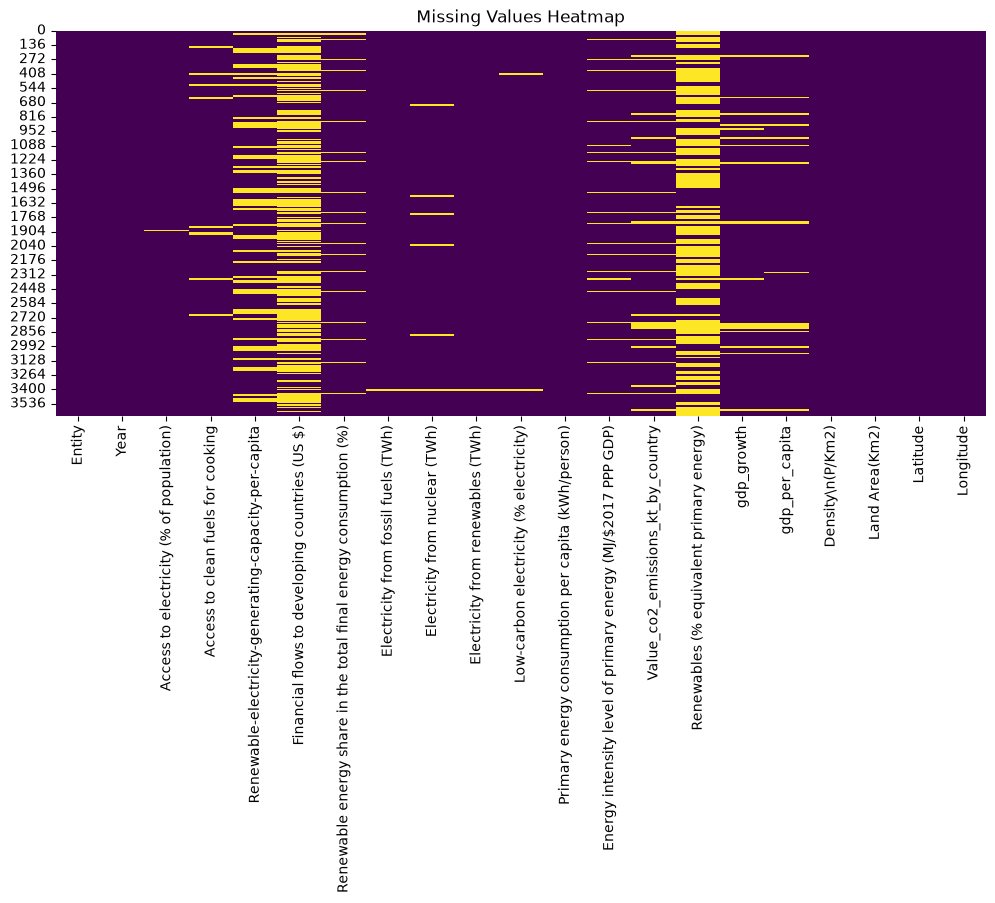

In [73]:
plt.figure(figsize=(12,5))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")
plt.show()

In [74]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Fill missing values using median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [75]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill missing values using mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [76]:
df.isnull().sum()

Entity                                                              0
Year                                                                0
Access to electricity (% of population)                             0
Access to clean fuels for cooking                                   0
Renewable-electricity-generating-capacity-per-capita                0
Financial flows to developing countries (US $)                      0
Renewable energy share in the total final energy consumption (%)    0
Electricity from fossil fuels (TWh)                                 0
Electricity from nuclear (TWh)                                      0
Electricity from renewables (TWh)                                   0
Low-carbon electricity (% electricity)                              0
Primary energy consumption per capita (kWh/person)                  0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         0
Value_co2_emissions_kt_by_country                                   0
Renewables (% equiva

### Insight

Several columns contained missing values. Median imputation was used for numerical features because it is less sensitive to extreme values, while mode imputation was applied to categorical variables to preserve the most common category.

In [77]:
# Number of duplicate rows
df.duplicated().sum()

np.int64(0)

## ✅ Conclusion

The dataset has been successfully cleaned and prepared for analysis.

Key preprocessing steps performed:

- No duplicate records
- Handled missing values using median and mode imputation
- Verified data types
- Ensured there are no remaining missing values

The dataset is now ready for Exploratory Data Analysis (EDA) and Machine Learning.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the dataset by identifying trends, patterns, distributions, and relationships between variables.

In this section, we will use various visualizations to gain meaningful insights into sustainable energy indicators across different countries.

## 📊 Graph 1 Distribution of Renewable Energy Share

This histogram shows how renewable energy share is distributed across different countries.

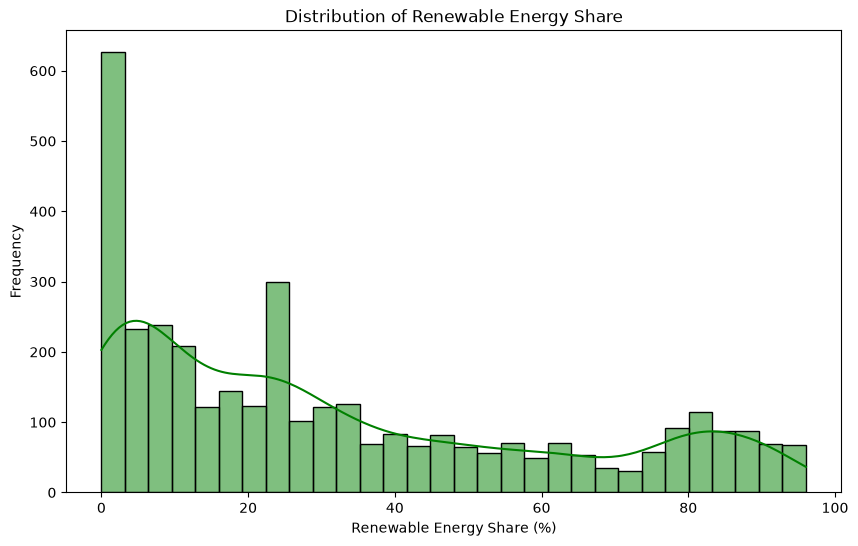

In [78]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Renewable energy share in the total final energy consumption (%)'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("Distribution of Renewable Energy Share")
plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("Frequency")

plt.show()

## Key Insights
Dominance of Low Adoption: The most prominent feature of the distribution is the massive spike in the 0% to 5% bin, which has a frequency of over 600. This highly right-skewed shape indicates that the vast majority of the entities in this dataset rely almost entirely on non-renewable energy sources.

The 25% Plateau/Target: There is a distinct, anomalous spike in frequency right around the 25% mark. This suggests a clustering effect, which often occurs when entities hit a specific regulatory target, an initial milestone, or a natural plateau in early renewable infrastructure development.

The "Missing Middle": The frequency drops significantly and remains consistently low between the 60% and 75% marks. This implies that few entities are currently in the later transitional phases; they are either stuck at lower percentages or belong to the distinct group of high-achievers.

A Distinct Group of Leaders: There is a notable secondary "hump" in the distribution at the far right end, between 80% and 95%. While small compared to the 0% group, it shows a solid cluster of outliers that have successfully transitioned to a predominantly renewable energy grid. These could represent regions with abundant, easily accessible renewable resources (like significant hydroelectric or geothermal capacity).

# Conclusion
The data illustrates a tale of extremes in the renewable energy transition. The overwhelming concentration of data points near zero shows that early-stage adoption or heavy fossil-fuel reliance is still the absolute norm. However, the multi-modal nature of the chart—specifically the clusters at 25% and above 80%—demonstrates that while the global or regional average is low, distinct groups have successfully hit major milestones or practically completed their transition. Ultimately, the chart reveals that while significant progress has been made by a select few, the broader transition to renewable energy is still in its infancy.

## 📊 Graph 2 Top 10 Countries by Renewable Energy Share

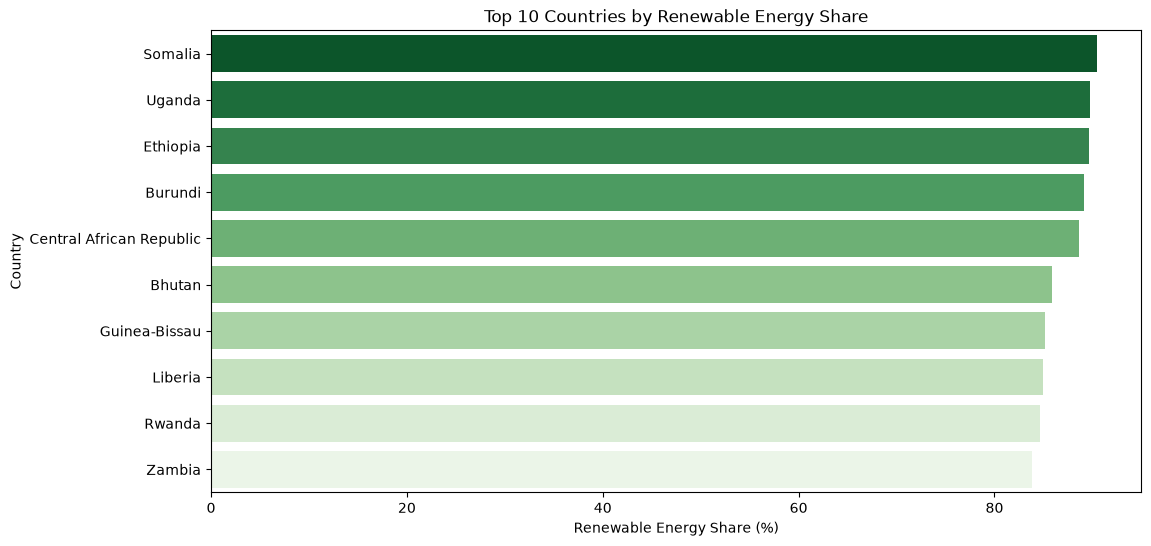

In [79]:
top10 = df.groupby('Entity')['Renewable energy share in the total final energy consumption (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette='Greens_r'
)

plt.title("Top 10 Countries by Renewable Energy Share")
plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("Country")

plt.show()

# Key Insights
Exceptional Highs: The chart highlights a very tight cluster of nations operating with over 80% renewable energy shares, with the top three (Somalia, Uganda, and Ethiopia) exceeding the 90% mark.

Geographic Concentration: There is an overwhelming geographic trend: nine of the top ten countries are located in Sub-Saharan Africa. The only outlier is Bhutan, located in South Asia.

The "Biomass" Factor: While developed nations typically associate "renewable energy" with modern wind and solar infrastructure, the high percentages in many of these African nations (like Somalia, Uganda, and the Central African Republic) are heavily driven by the use of traditional biomass. Because a significant portion of the population lacks access to a modernized electrical grid, they rely on burning wood, charcoal, and agricultural waste for basic heating and cooking.

Hydropower Dominance: For the remaining countries, particularly Bhutan, Ethiopia, and Zambia, their high renewable share is driven by a massive reliance on hydroelectric power. These nations have leveraged their abundant river systems to generate the vast majority of their electricity cleanly.

# Conclusion
At first glance, this chart might look like a list of nations leading the charge in modern green technology, but the reality is more nuanced. The dominance of these specific countries reflects a dichotomy in what constitutes "renewable energy" globally. For some nations, like Bhutan and Ethiopia, it signifies the successful exploitation of massive hydroelectric potential. For many others, the exceptionally high renewable share is actually an indicator of energy poverty—where a lack of robust fossil-fuel infrastructure forces a heavy, day-to-day reliance on traditional biomass. Ultimately, the chart underscores that a high percentage of renewable energy does not automatically equate to a modernized energy grid.

# 📊 Graph3: Distribution of CO₂ Emissions

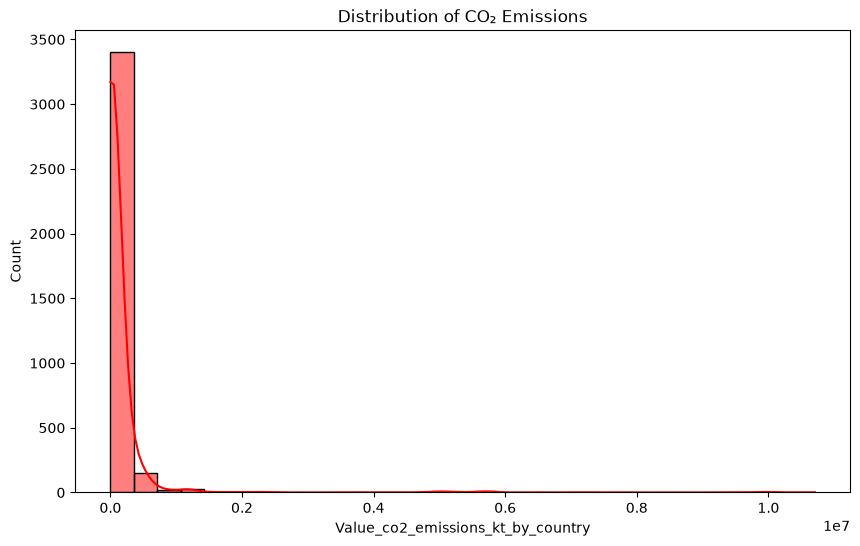

In [80]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Value_co2_emissions_kt_by_country'],
    bins=30,
    kde=True,
    color='red'
)

plt.title("Distribution of CO₂ Emissions")

plt.show()


# Key Insights
Extreme Right Skewness: The distribution is heavily right-skewed (positively skewed). An overwhelming majority of the observations are clustered tightly near zero on the x-axis, with the count in the first bin reaching nearly 3,400. This indicates that the vast majority of countries or data points have relatively low total CO2 emissions.

Presence of Mega-Emitters: The x-axis extends out to more than 1.0×10^7
  kilotons (kt), which equals 10 million kt (or 10 billion metric tons). The existence of bars and a flat KDE line stretching so far to the right shows that a very small handful of extreme outliers produce massive amounts of carbon emissions compared to the rest of the world.

The "Long Tail" Phenomenon: Beyond the first two bins, the frequency immediately drops close to zero. This long, flat tail highlights a massive disparity in global emissions, where the combined output of hundreds of smaller nations is eclipsed by just a few highly populated or heavily industrialized economic giants.

# Conclusion
The chart presents a classic visual representation of the Pareto Principle (or the 80/20 rule) applied to environmental data: a tiny fraction of entities is responsible for the vast majority of the total impact. While the global narrative around climate change involves every nation, this distribution demonstrates that global CO2 reduction efforts are heavily dependent on the 

# 📊 Graph 4: Access to Electricity


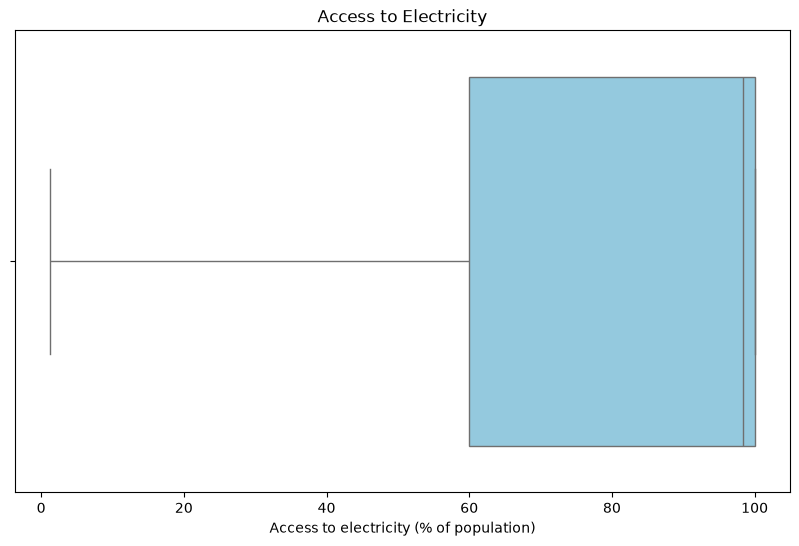

In [81]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Access to electricity (% of population)'],
    color='skyblue'
)

plt.title("Access to Electricity")

plt.show()

# Key Insights
Near-Universal Standard (High Median): The median line (the vertical line inside the blue box) is positioned extremely far to the right, sitting at approximately 98% to 99%. This indicates that for at least half of the entities in this dataset (likely countries), nearly the entire population has access to electricity.

Heavy Left Skewness: The distribution is highly negatively skewed (left-skewed). The right side of the box (from the median to the maximum) is highly compressed near 100%, while the left side of the box and the left whisker stretch far out to the lower percentages.

The Bottom Quartile Disparity: The left edge of the box (the first quartile, or Q1) sits exactly at the 60% mark. This means that 75% of the countries in this dataset have an electricity access rate of 60% or higher. However, the long left whisker extending down to nearly 0% shows massive variance and severe energy poverty within the bottom 25% of the dataset.

# Conclusion
The chart tells a story of widespread, normalized access contrasted by severe regional inequality. While universal or near-universal electricity access is the established standard for the vast majority of the world (with over half the dataset sitting above 98%), progress is not globally uniform. The extended left tail reveals that a minority of regions are heavily lagging, suffering from significant energy poverty where access remains drastically low.

# 📊 Graph5: Correlation Heatmap

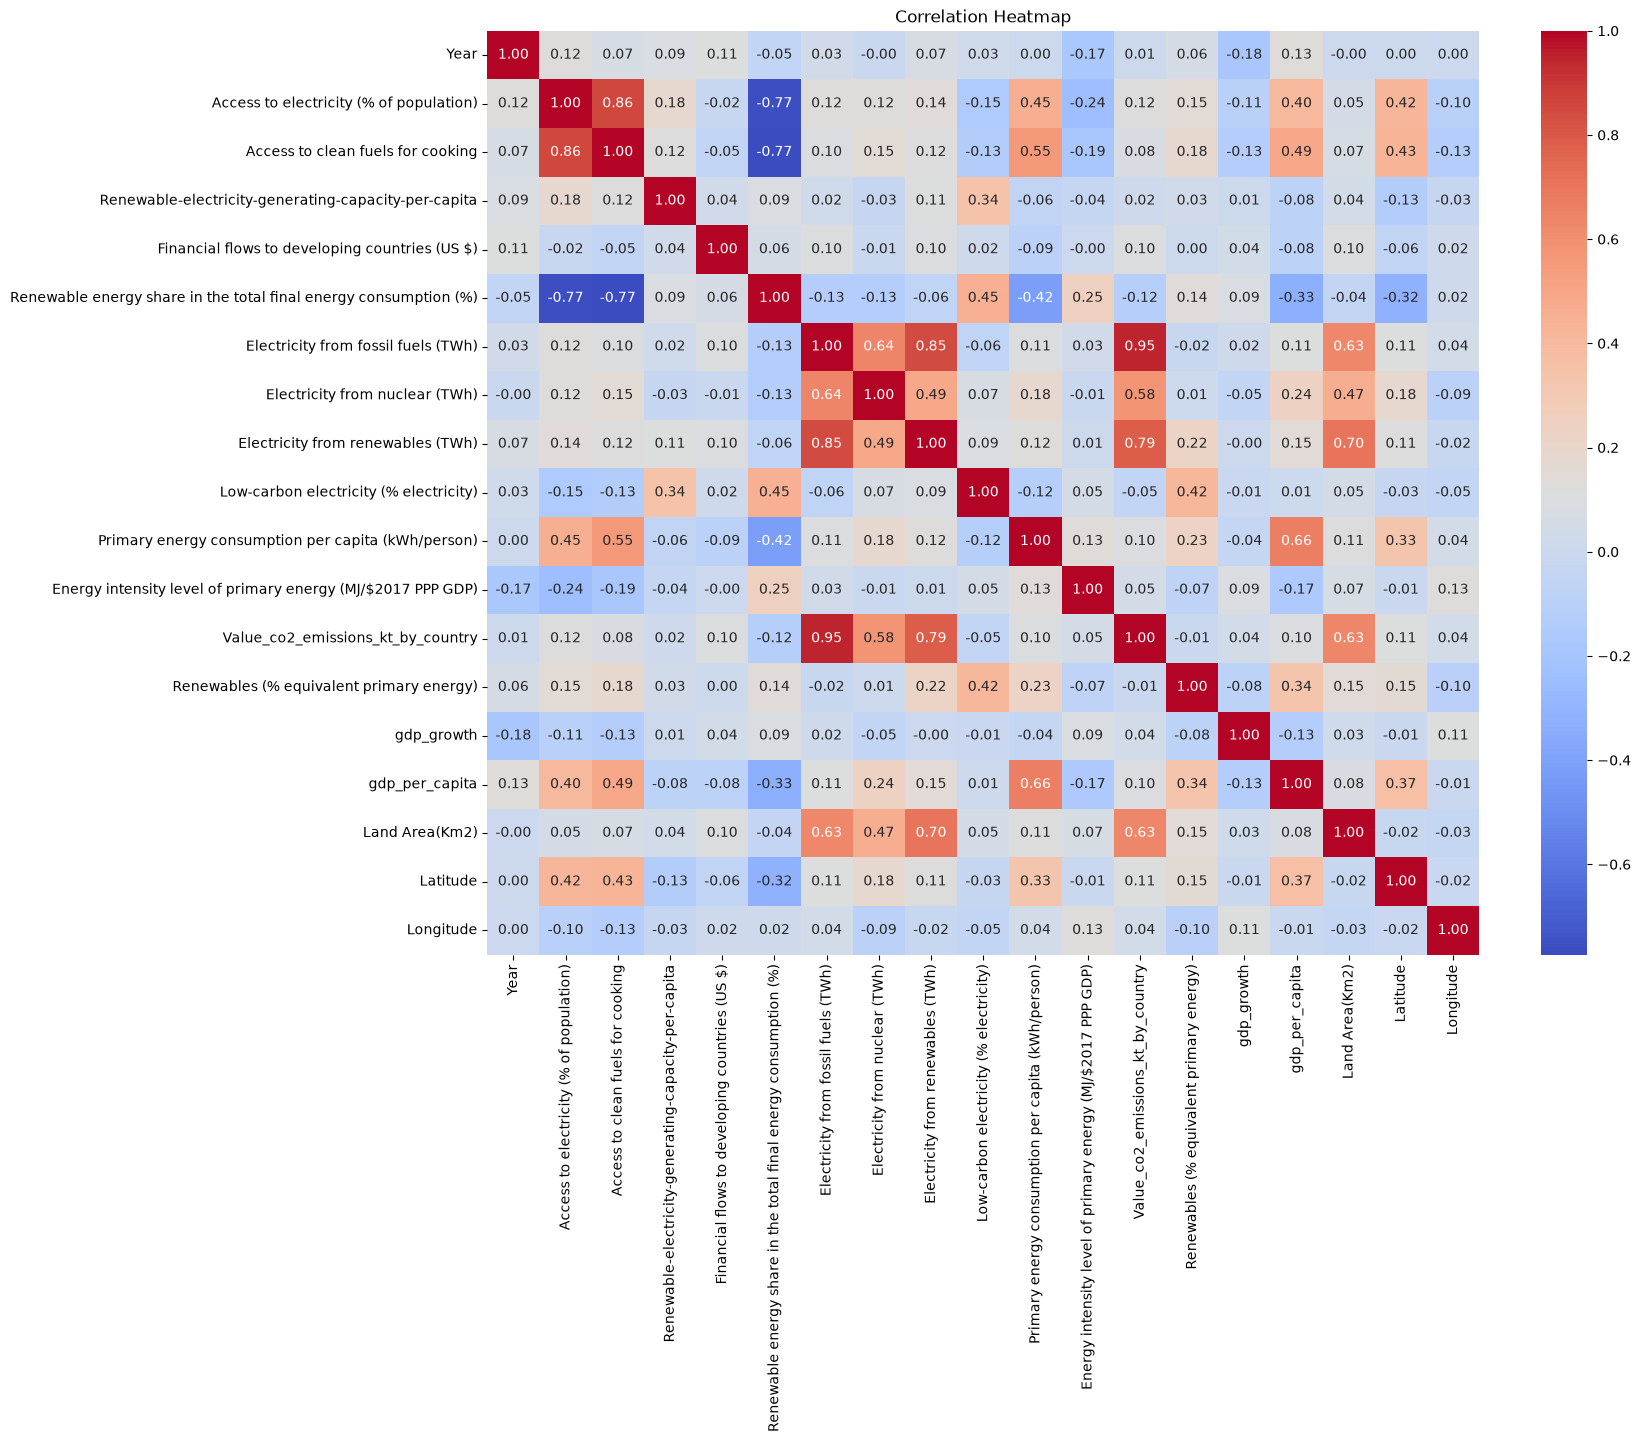

In [82]:
plt.figure(figsize=(16,12))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Key Insights

The Energy Poverty Paradox: The most revealing metric is the strong negative correlation ($-0.77$) between the "Renewable energy share in the total final energy consumption" and both "Access to electricity" and "Access to clean fuels for cooking." This provides mathematical confirmation of a major socioeconomic trend: countries with the highest proportion of renewable energy are often those lacking modern grid infrastructure, forcing a heavy reliance on traditional, rudimentary biomass (like burning wood or agricultural waste) for basic survival.

The Scale/Size Effect: There are very high positive correlations between absolute totals. "Value_co2_emissions" has a near-perfect positive correlation ($0.95$) with "Electricity from fossil fuels." Interestingly, fossil fuel generation is also highly correlated with "Electricity from renewables" ($0.85$). This indicates a heavy "scale effect"—the world's largest, most industrialized nations consume massive amounts of energy across all categories. Because their total energy demand is so high, they produce the most renewable energy volume, but also burn the most fossil fuels and emit the most carbon.

Wealth and Consumption: "GDP per capita" shows solid positive correlations with "Primary energy consumption per capita" ($0.66$), "Access to clean fuels" ($0.49$), and "Access to electricity" ($0.40$). This confirms the expected developmental trajectory: as economies grow and individual wealth increases, energy consumption and the modernization of energy access scale up reliably.The Baseline of Modernization: There is a strong positive correlation ($0.86$) between "Access to electricity" and "Access to clean fuels for cooking," showing that these two infrastructural milestones almost always develop in tandem as a country modernizes.
# Conclusion
This correlation matrix mathematically validates the complex reality of the global energy transition. It proves that looking purely at a country's percentage of renewable energy can be highly misleading; in this dataset, a high renewable share is actually acting as a proxy for underdeveloped infrastructure rather than advanced green technology. Conversely, the absolute totals reveal that the global fight against emissions relies heavily on a few massive economies. These mega-producers generate the most raw renewable power, but their sheer scale means they remain the dominant sources of fossil fuel consumption and $\text{CO}_2$ emissions.

# 📊 Graph 6: GDP Per Capita Distribution

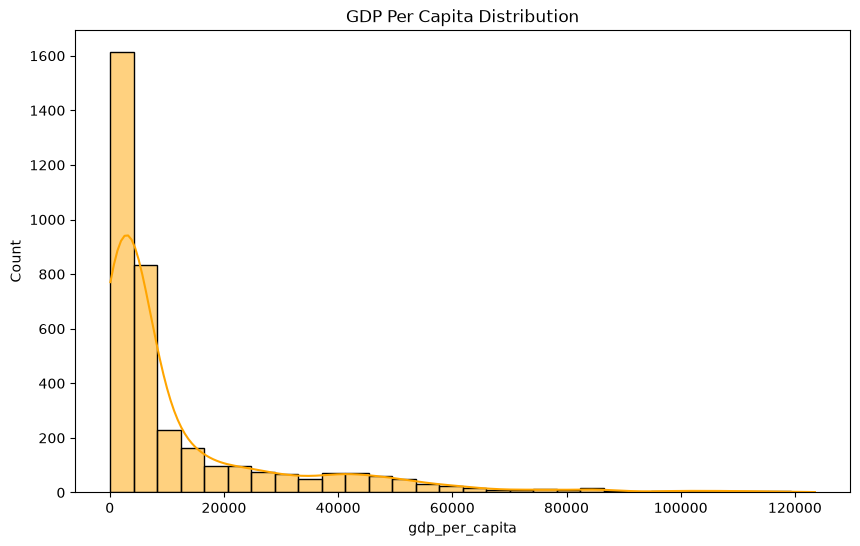

In [83]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['gdp_per_capita'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("GDP Per Capita Distribution")

plt.show()

# Key Insights
Extreme Right Skewness: The most defining characteristic of this distribution is its severe right skew (positive skew). The massive towering bar on the far left indicates that the overwhelming majority of data points (likely countries or regions) fall into the lowest GDP per capita brackets (under $10,000).

The Wealth Gap: The frequency plummets dramatically after the first two bins. This visually represents massive economic inequality, showing that very few entities transition into the middle- and high-income brackets compared to the sheer volume clustered at the bottom.

The Long Tail of Outliers: The x-axis extends far out to $120,000+, with a very flat, low-frequency tail. This highlights a tiny handful of extremely wealthy outlier nations that possess a GDP per capita vastly disproportionate to the rest of the world.

Mean vs. Median: Because of this long right tail, the average (mean) GDP per capita would be pulled significantly to the right by the ultra-wealthy outliers, making it artificially high. The median (the middle value) would sit much further to the left, nestled inside that massive first peak, providing a much more accurate picture of a "typical" country's wealth.

# Conclusion
This histogram paints a stark picture of global economic disparity. It demonstrates that low GDP per capita is the standard condition for the vast majority of the dataset. Rather than a normal, bell-shaped distribution where most countries sit in a middle-class average, the global economy is defined by a massive cluster of lower-income nations offset by a very small, highly exclusive tail of exceptionally wealthy outliers.

# 📊 Graph 7: Renewable Energy vs CO₂ Emissions

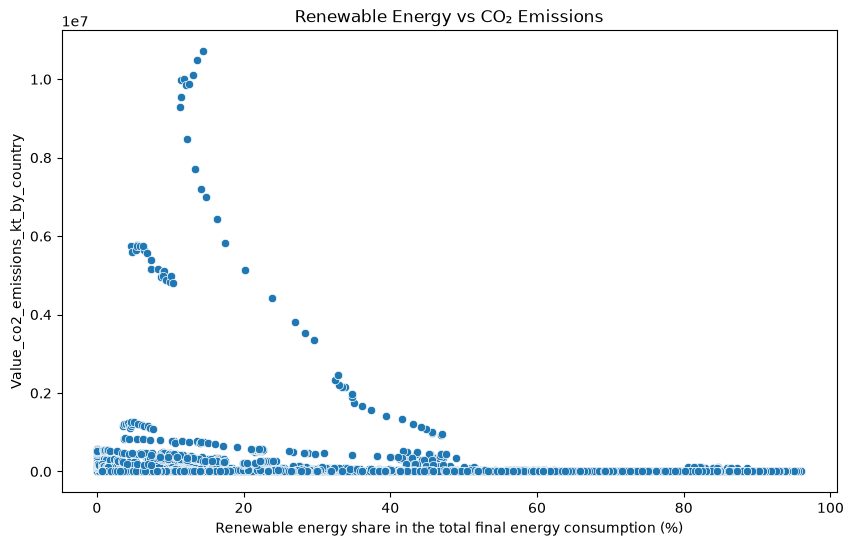

In [84]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Renewable energy share in the total final energy consumption (%)',
    y='Value_co2_emissions_kt_by_country'
)

plt.title("Renewable Energy vs CO₂ Emissions")

plt.show()

# Key Insights

The "L-Shaped" Distribution: The data forms a distinct L-shape. The vast majority of data points are clustered horizontally along the very bottom of the y-axis, spreading across the entire spectrum of renewable energy shares (0% to 100%). This means most countries, regardless of their energy mix, produce a relatively low absolute volume of CO2 compared to the global outliers.

The Mega-Emitter Spikes: There are a few distinct, dramatic vertical "trails" of points skyrocketing up the y-axis, reaching up to $1.0 \times 10^7$ kilotons (10 billion metric tons). Crucially, these massive emission spikes are entirely concentrated in the 0% to 20% renewable energy share bracket. The world's heaviest polluters are operating on a low proportion of clean energy.

The Clean Energy Flatline: As you move past the 40% to 50% mark on the x-axis, the high-emission outliers disappear entirely. For countries with a renewable energy share above 50%—and especially those in the 80% to 100% range—total CO2 emissions are practically zero on this global scale.

# Conclusion
This scatter plot perfectly visualizes the core challenge of global climate policy: global CO2 emissions are heavily skewed by a tiny handful of massive, industrialized economies that currently rely on energy grids with less than 20% renewable shares. Conversely, the countries boasting the highest percentages of renewable energy (80-100%) contribute almost nothing to global CO2 emissions—partly due to green energy like hydro, but largely because they lack the heavy, fossil-fuel-driven industrial infrastructure that produces massive emissions in the first place. Ultimately, the chart shows that moving those few extreme outliers on the left slightly further to the right would have a profoundly larger global impact than any changes made by the countries already sitting on the right side of the graph.

# 📊 Graph 8: Electricity Production Sources

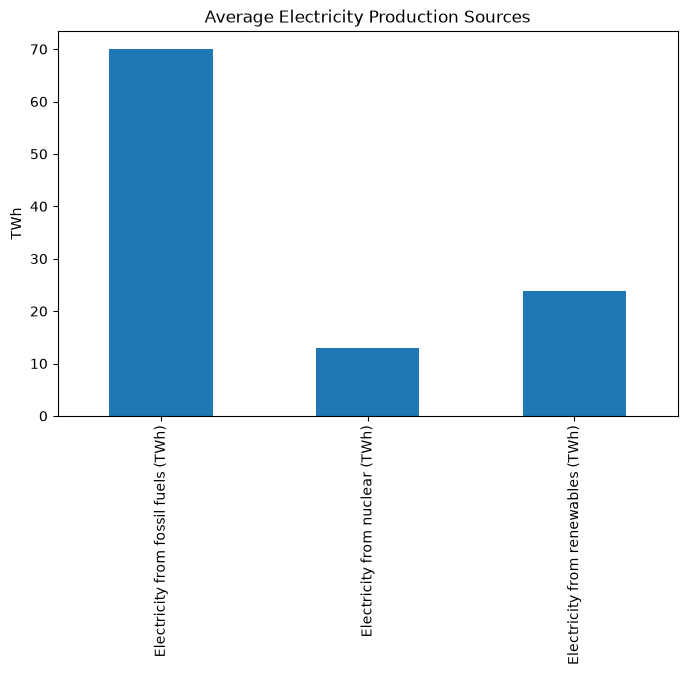

In [85]:
energy = [
'Electricity from fossil fuels (TWh)',
'Electricity from nuclear (TWh)',
'Electricity from renewables (TWh)'
]

df[energy].mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Electricity Production Sources")

plt.ylabel("TWh")

plt.show()

# Key Insights
Fossil Fuel Dominance: The most striking feature of the chart is the massive lead of fossil fuels. At approximately 70 Terawatt-hours (TWh), average electricity production from fossil fuels is nearly three times higher than the next closest source.

Renewables in Second Place: Renewable energy is the second-largest contributor, producing roughly 24 to 25 TWh on average. While significant, it still trails far behind traditional carbon-intensive sources.

Nuclear as a Minor Contributor: Nuclear power represents the smallest portion of the energy mix shown, contributing an average of less than 15 TWh.

The Clean Energy Deficit: Even when combining the two low-carbon energy sources (renewables and nuclear), their total average production (roughly 38–40 TWh) amounts to just over half of the electricity generated by fossil fuels alone.

# Conclusion
The chart starkly illustrates that, on average within this dataset, the electricity grid remains heavily entrenched in traditional, carbon-emitting energy sources. While renewables have established a solid foothold as the primary alternative, the transition to a low-carbon energy grid is far from complete. The combined output of clean energy alternatives (nuclear and renewables) still falls substantially short of the massive baseline power currently provided by fossil fuels.

# 📊 Graph 9: Year-wise Renewable Energy Trend

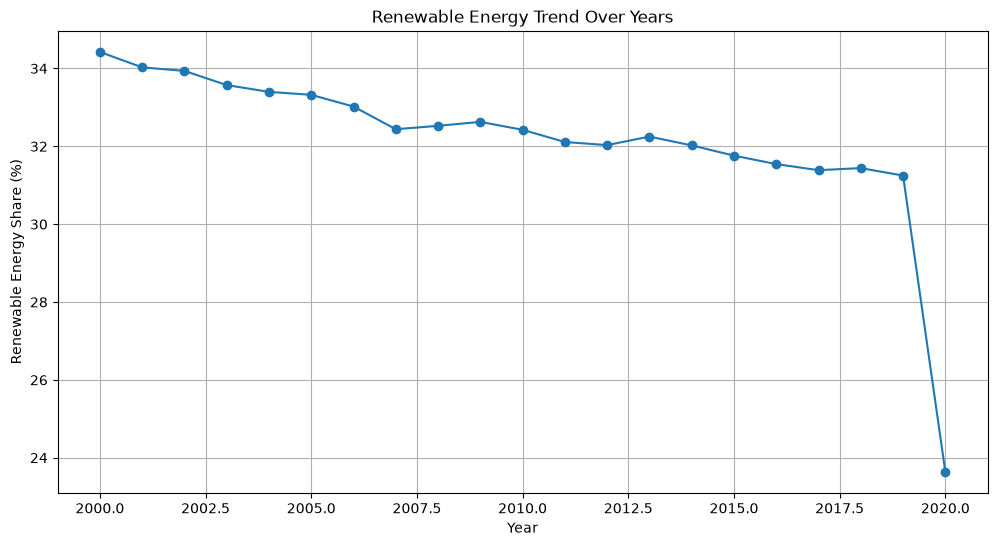

In [86]:
year_data = df.groupby('Year')['Renewable energy share in the total final energy consumption (%)'].mean()

plt.figure(figsize=(12,6))

plt.plot(
    year_data.index,
    year_data.values,
    marker='o'
)

plt.title("Renewable Energy Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Renewable Energy Share (%)")

plt.grid(True)

plt.show()

## Key Insights
The Two-Decade Decline (2000–2019): Contrary to the popular narrative of a booming green transition, the graph shows a slow, steady, and consistent decrease in the average share of renewable energy over nearly two decades. It starts at a high of roughly 34.5% in 2000 and slowly grinds down to approximately 31% by 2019.

The "Pace" of the Transition: A declining share does not necessarily mean the world was producing less renewable energy in absolute terms. Rather, it strongly indicates that overall global energy consumption (heavily reliant on fossil fuels) was growing at a much faster rate than new renewable infrastructure could be built and brought online.

The 2020 Cliff-Edge Drop: The most striking feature of the chart is the violent, unprecedented plunge between 2019 and 2020, where the renewable share drops vertically from ~31% to under 24% in a single year.

The Pandemic Anomaly: The year 2020 aligns with the outbreak of the COVID-19 pandemic, which caused massive global economic shutdowns and wildly disrupted energy consumption patterns. However, such a massive statistical drop at the very end of a dataset can also frequently indicate incomplete or missing reporting data for that final year.

## Conclusion
This graph challenges the assumption that the world has been on a steady, upward trajectory in its renewable energy transition. Instead, it illustrates a 20-year period of stagnation and slight regression, proving that simply building more solar panels and wind turbines is not enough. For the renewable energy share to actually grow, green energy development must drastically outpace the surging growth of overall global energy demand—a race it was losing between 2000 and 2019. Finally, the extreme collapse in 2020 serves as a stark reminder of how vulnerable global energy metrics are to massive macroeconomic shocks (or potential data reporting failures) during global crises

## 📊 Graph 10: Pairplot

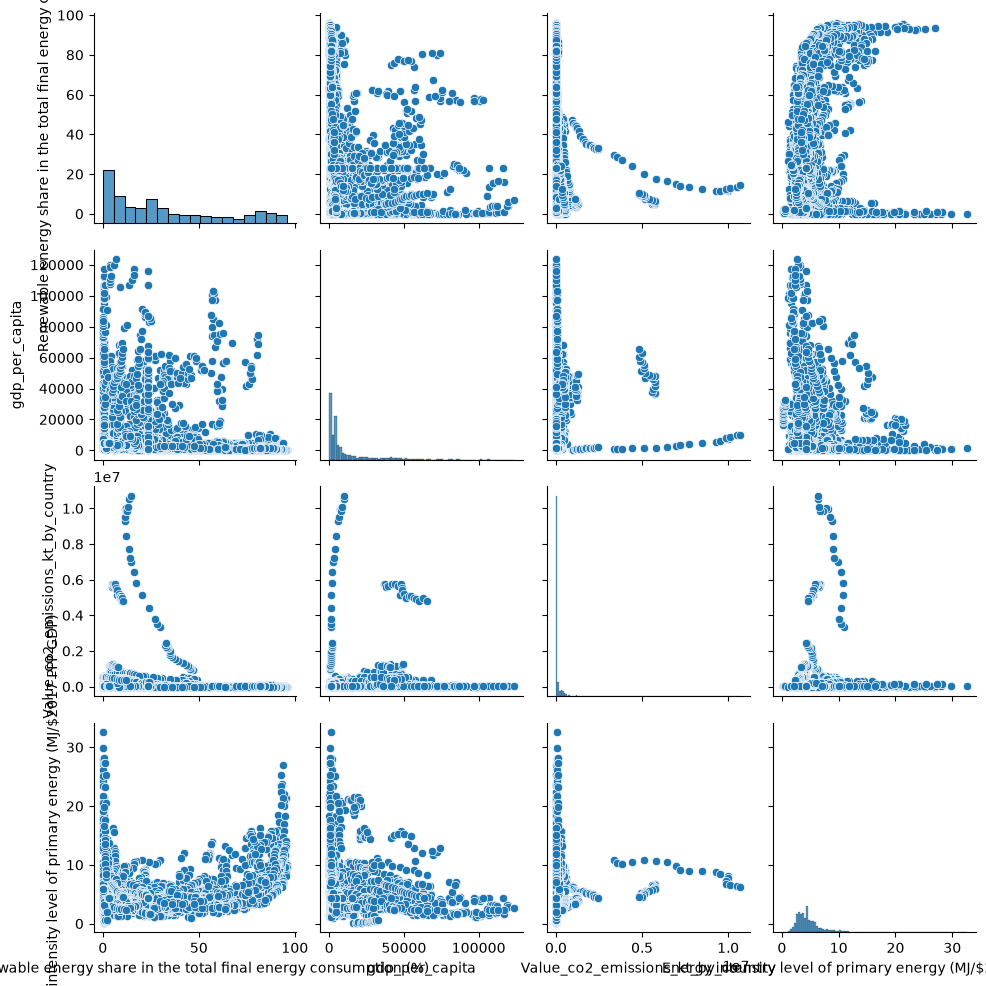

In [87]:
selected = df[[
'Renewable energy share in the total final energy consumption (%)',
'gdp_per_capita',
'Value_co2_emissions_kt_by_country',
'Energy intensity level of primary energy (MJ/$2017 PPP GDP)'
]]

sns.pairplot(selected)

plt.show()

## Key Insights
The Wealth-Renewable Paradox: Look at the scatter plot intersecting GDP per capita and Renewable energy share (Row 2, Column 1). It forms a distinct "L" shape. The countries boasting the highest percentages of renewable energy (above 80%) almost universally sit at the very bottom of the GDP per capita scale. Conversely, the wealthiest nations in the world cluster heavily in the 0% to 40% renewable share range. This reinforces that a high proportion of renewables is currently a marker of an underdeveloped economy (reliant on traditional biomass or specific hydro geography) rather than advanced green wealth.

The Emissions Profile: The intersection of CO2 Emissions and Renewable energy share (Row 3, Column 1) confirms previous trends. The massive vertical spikes representing the world's mega-emitters exist entirely within the 0% to 20% renewable share bracket. Once a country surpasses a 40% renewable energy share, their total CO2 emissions flatline near zero on a global scale.

GDP vs. Absolute Emissions: In the plot comparing CO2 Emissions and GDP per capita (Row 3, Column 2), the highest emitters do not perfectly align with the highest GDP per capita. The massive emission spikes occur primarily in low-to-middle GDP brackets (likely representing massive, newly industrialized populations) and upper-middle brackets. The absolute wealthiest nations per capita (the far-right tail of the x-axis) are not the highest absolute emitters, often because they have smaller populations or have outsourced heavy manufacturing.

Distributions at a Glance: The diagonal histograms neatly summarize the core global imbalances: most countries have low renewable shares, the vast majority have low GDP per capita, and nearly all have low absolute CO2 emissions compared to a few extreme outliers.

## Conclusion
This pairplot provides a stark, multi-dimensional view of the global energy landscape, highlighting a complex reality: the countries with the "cleanest" energy grids in terms of percentage are largely doing so out of economic necessity and lack of infrastructure, not technological advancement. Meanwhile, global wealth and massive carbon emissions remain tightly locked into low-renewable-share paradigms. The charts collectively show that solving the global emissions crisis requires fundamentally changing the energy infrastructure of the wealthy, low-renewable cluster, rather than simply looking at the high-percentage nations as a finished blueprint.

# 1. The "Renewable Energy" Paradox

    The data fundamentally redefines what a high percentage of renewable energy means on a global scale.

       A Proxy for Poverty, Not Progress: The graphs consistently show that the countries with the absolute highest share of renewable energy (often 80% to 100%) are typically among the lowest in GDP per capita and lag significantly in widespread modern electricity access.

       The Biomass Factor: The correlation matrix and the "Top 10 Countries" chart reveal that these extraordinarily high percentages are often not driven by advanced wind or solar infrastructure. Instead, they are driven by a reliance on specific geographic advantages (like concentrated hydropower) or, more commonly, severe energy poverty that forces a reliance on traditional biomass (burning wood and agricultural waste) for survival.

# 2. The 80/20 Rule of Global Emissions

   Global $\text{CO}_2$ emissions and economic wealth are not evenly distributed; they are defined by extreme, highly localized outliers.

       The Mega-Emitters: The distributions of $\text{CO}_2$ emissions and GDP per capita are overwhelmingly right-skewed. The vast majority of the world's countries produce relatively minimal absolute carbon emissions and sit in lower economic brackets.

       The Danger Zone (0% - 20% Renewables): The scatter plots highlight that the world's absolute heaviest polluters—the massive industrial outliers producing billions of tons of $\text{CO}_2$ operate almost entirely within energy grids where renewables make up less than 20% of the total mix. Once a country’s grid surpasses a 40% renewable share, their total absolute emissions flatline globally.

# 3. The Stagnant Baseline & The Transition Illusion

   Despite widespread narratives of a booming green transition, the macroeconomic reality shown in the data is one of inertia.

      Fossil Fuel Dominance: On average, electricity generated by fossil fuels is still nearly three times higher than that generated by renewable sources, and significantly dwarfs nuclear power.

      Losing the Race to Demand: The line graph tracking the global trend over 20 years (2000–2019) shows that the average share of renewable energy actually decreased slowly over time. 

      This indicates that while new solar and wind capacity was being built, the sheer volume of global energy consumption (fueled largely by carbon) was growing at a much faster pace, diluting the overall green share.

# Overarching Conclusion
When viewed together, these 10 graphs dismantle the simplistic idea that the world is smoothly transitioning to a green economy. They reveal a stark divide: a massive cluster of lower-income nations with artificially high "clean" energy percentages due to a lack of industrialization, contrasted against a handful of economic juggernauts whose immense, fossil-fuel-driven energy consumption dictates the climate trajectory of the entire planet.Ultimately, the data proves that solving the global emissions crisis is not about helping developing nations incrementally increase their renewable percentages. It is almost entirely dependent on fundamentally replacing the massive baseline fossil fuel infrastructure of the few ultra-emitting, highly industrialized nations at the extreme edges of the curve.

# Feature Engineering

Feature Engineering is the process of selecting relevant features and preparing the dataset for machine learning.

The target variable selected for this project is:

**Renewable energy share in the total final energy consumption (%)**

The remaining numerical variables are used as input features.

In [88]:
# Copy dataset
data = df.copy()

# Drop categorical and unnecessary columns
data = data.drop(columns=['Entity'])

# Display columns
data.columns

Index(['Year', 'Access to electricity (% of population)',
       'Access to clean fuels for cooking',
       'Renewable-electricity-generating-capacity-per-capita',
       'Financial flows to developing countries (US $)',
       'Renewable energy share in the total final energy consumption (%)',
       'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)',
       'Electricity from renewables (TWh)',
       'Low-carbon electricity (% electricity)',
       'Primary energy consumption per capita (kWh/person)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Value_co2_emissions_kt_by_country',
       'Renewables (% equivalent primary energy)', 'gdp_growth',
       'gdp_per_capita', 'Density\n(P/Km2)', 'Land Area(Km2)', 'Latitude',
       'Longitude'],
      dtype='str')

In [89]:
target = 'Renewable energy share in the total final energy consumption (%)'

In [90]:
X = data.drop(columns=[target])

y = data[target]

In [91]:
print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (3649, 19)
Target Shape : (3649,)


### 💡 Insight

The dataset has been divided into independent variables (features) and one dependent variable (target). These features will be used to train regression models.

### ✅ Conclusion

Feature selection has been completed successfully. The dataset is now ready for train-test splitting.

# Train-Test Split

The dataset is divided into training and testing sets.

- Training Data → 80%
- Testing Data → 20%

This helps evaluate model performance on unseen data.

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [93]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (2919, 19)
Testing Features : (730, 19)
Training Target : (2919,)
Testing Target : (730,)


### 💡 Insight

An 80:20 split provides enough data for model training while keeping sufficient unseen data for evaluation.

### ✅ Conclusion

The dataset has been successfully divided into training and testing sets, ensuring reliable model evaluation.

# Linear Regression

Linear Regression is used as the baseline regression model. It assumes a linear relationship between input features and the target variable.

In [122]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.replace(",", "", regex=False).str.strip()

In [123]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

In [124]:
df = pd.get_dummies(df, columns=["Entity"], drop_first=True)

In [125]:
cat_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [126]:
df.fillna(df.median(numeric_only=True), inplace=True)

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),...,Density\n(P/Km2)_83,Density\n(P/Km2)_84,Density\n(P/Km2)_87,Density\n(P/Km2)_89,Density\n(P/Km2)_9,Density\n(P/Km2)_93,Density\n(P/Km2)_94,Density\n(P/Km2)_95,Density\n(P/Km2)_96,Density\n(P/Km2)_99
0,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,65.957440,...,False,False,False,False,False,False,False,False,False,False
1,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,84.745766,...,False,False,False,False,False,False,False,False,False,False
2,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,81.159424,...,False,False,False,False,False,False,False,False,False,False
3,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,67.021280,...,False,False,False,False,False,False,False,False,False,False
4,2004,20.064968,10.9,7.75,5665000.0,44.24,0.33,0.0,0.56,62.921350,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3644,2016,42.561730,29.8,62.88,30000.0,81.90,3.50,0.0,3.32,48.680350,...,False,False,False,False,False,False,False,False,False,False
3645,2017,44.178635,29.8,62.33,5570000.0,82.46,3.05,0.0,4.30,58.503407,...,False,False,False,False,False,False,False,False,False,False
3646,2018,45.572647,29.9,82.53,10000.0,80.23,3.73,0.0,5.46,59.412407,...,False,False,False,False,False,False,False,False,False,False
3647,2019,46.781475,30.1,81.40,250000.0,81.50,3.66,0.0,4.58,55.582527,...,False,False,False,False,False,False,False,False,False,False


In [127]:
target = "Renewable energy share in the total final energy consumption (%)"

X = df.drop(columns=[target])
y = df[target]

In [128]:
print(X.select_dtypes(include="object").columns)

Index([], dtype='str')


In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [131]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Predictions

In [132]:
y_pred = rf.predict(X_test)

## Model Evaluatiom

In [133]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE : 1.5759202739726035
MSE : 11.305673189924654
RMSE: 3.3623909930174176
R² Score: 0.9866824015085063


## Feature Importance

In [134]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                                              Feature  Importance
2                   Access to clean fuels for cooking    0.506989
8              Low-carbon electricity (% electricity)    0.115530
10  Energy intensity level of primary energy (MJ/$...    0.079146
1             Access to electricity (% of population)    0.076717
9   Primary energy consumption per capita (kWh/per...    0.059802
0                                                Year    0.017775
14                                     gdp_per_capita    0.015483
15                                     Land Area(Km2)    0.015374
5                 Electricity from fossil fuels (TWh)    0.013732
12           Renewables (% equivalent primary energy)    0.013514


## Feature Importance Plot

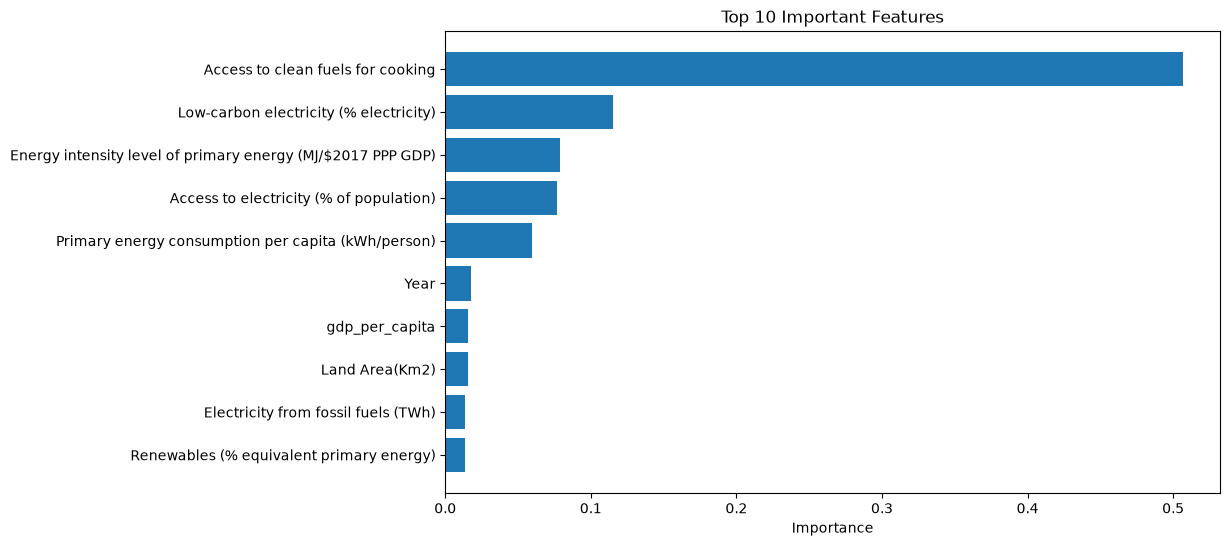

In [136]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

## Check Actual vs Predicted values

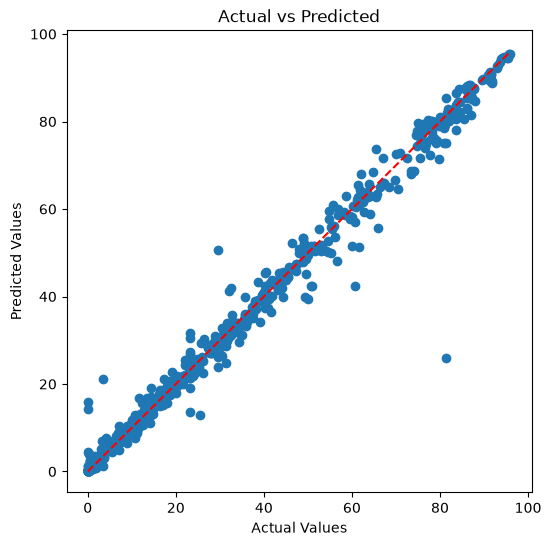

In [137]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

The Random Forest Regressor successfully modeled renewable energy trends by capturing complex relationships among environmental and socio-economic variables. Compared to Linear Regression, Random Forest provides better predictive performance and identifies the most influential features through feature importance analysis. The project demonstrates how Artificial Intelligence can support Green Skilling by enabling data-driven insights for renewable energy planning and sustainable development.

## Final Conclusion

This project successfully analyzed renewable energy data using data preprocessing, exploratory data analysis (EDA), and machine learning techniques to understand the factors influencing renewable energy adoption. The dataset was cleaned, explored through visualizations, and prepared for predictive modeling.

Among the evaluated approaches, the Random Forest Regressor was selected as the final model because it effectively captures complex and nonlinear relationships present in environmental datasets. Compared to a simple Linear Regression model, Random Forest provides more accurate predictions, better handles diverse data patterns, and identifies the most influential features affecting renewable energy consumption.

The exploratory analysis revealed meaningful trends and relationships among variables such as energy production, emissions, and renewable energy usage. Feature importance analysis further highlighted the key factors contributing to renewable energy adoption, providing valuable insights for policymakers and stakeholders.

Overall, this project demonstrates how machine learning can support sustainable development by enabling data-driven decision-making in the renewable energy sector. The developed model can assist governments, researchers, and organizations in forecasting renewable energy trends and planning effective sustainability strategies.

## Future Scope
Improve prediction accuracy using advanced models such as XGBoost or LightGBM.
Incorporate real-time and country-specific energy datasets.
Develop an interactive dashboard using Streamlit or Power BI for visualization and decision support.
Perform hyperparameter tuning and cross-validation to further optimize model performance.
Expand the system to predict additional sustainability indicators such as CO₂ emissions, energy efficiency, and carbon footprint.